<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

# Model monitoring — score and feature drift

*Draft notebook — a narrative layer over the tested `src/`, not a re-implementation. The PSI detector (`PSIDetector`) and the SHAP-attribution drift (`attributions`, `attribution_ndcg`) are imported from the chapter's code and run here over a reference batch and a drifted one. On AWS the same code runs as a SageMaker Processing monitor emitting CloudWatch metrics — see `aws/`.*

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-cog" style="color:#18ab4b"></i>&nbsp; Parameters</h2>

Tagged `parameters` for papermill: `papermill monitoring.ipynb out.ipynb -p MODE aws` reads the drift metrics the managed monitor published to CloudWatch instead of computing them in-process.

In [1]:
# parameters
MODE = "local"  # "local": compute drift in-process  |  "aws": read CloudWatch metrics
REGION = "us-east-1"
NAMESPACE = "CreditScorecard/Monitoring"

In [2]:
import sys

import matplotlib.pyplot as plt
import pandas as pd
from catboost import CatBoostClassifier

# the tested monitoring code, imported not copied
sys.path.insert(0, "../src")
from attribution import attribution_ndcg, attributions
from model import CATEGORICAL, NUMERIC
from psi import PSIDetector

reference = pd.read_csv("../data/generated/reference.csv")
current = pd.read_csv("../data/generated/current.csv")
model = CatBoostClassifier()
model.load_model("../runs-local/model/scorecard.cbm")
f"{len(reference):,} reference rows, {len(current):,} current rows"

'9,000 reference rows, 6,000 current rows'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the row counts for the frozen reference set and the current production window:

```plain
'9,000 reference rows, 6,000 current rows'
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-database" style="color:#18ab4b"></i>&nbsp; The reference and the drifted batch</h2>

The monitor compares a *current* batch against the *reference* the model was trained on. A few feature means already show the shift the detectors will quantify.

In [3]:
pd.DataFrame(
    {
        "reference": reference[NUMERIC].mean(),
        "current": current[NUMERIC].mean(),
    }
).assign(
    pct_change=lambda d: (d["current"] / d["reference"] - 1).map("{:+.1%}".format)
).round(2)

,reference,current,pct_change
age,47.77,47.18,-1.2%
annual_income,55924.84,50228.32,-10.2%
debt_to_income,17.19,21.66,+26.0%
bureau_score,681.06,634.43,-6.8%
credit_utilization,40.26,53.34,+32.5%
employment_length_years,6.01,5.98,-0.5%
loan_amount,14480.90,14474.62,-0.0%


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** each numeric feature's reference and current mean, with the percentage shift between them:

```plain
                         reference   current pct_change
age                          47.77     47.18      -1.2%
annual_income             55924.84  50228.32     -10.2%
debt_to_income               17.19     21.66     +26.0%
bureau_score                681.06    634.43      -6.8%
credit_utilization           40.26     53.34     +32.5%
employment_length_years       6.01      5.98      -0.5%
loan_amount               14480.90  14474.62      -0.0%
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-wave-square" style="color:#18ab4b"></i>&nbsp; Population stability (PSI) of the features</h2>

`PSIDetector.from_catboost` bins each feature on the model's own split points (the boundaries the trees actually use), then measures how far the current batch's mass has moved from the reference. PSI above 0.2 is a material shift.

In [4]:
det = PSIDetector.from_catboost(model, reference, NUMERIC, CATEGORICAL)
psi = pd.Series(det.psi(current), name="PSI").sort_values(ascending=False)
psi.to_frame().round(4)

,PSI
bureau_score,0.7758
credit_utilization,0.5940
debt_to_income,0.3810
employment_status,0.0958
annual_income,0.0774
loan_amount,0.0296
employment_length_years,0.0172
age,0.0098
loan_purpose,0.0025
home_ownership,0.0001


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** the population stability index for every feature, ranked from most to least drifted:

```plain
                            PSI
bureau_score             0.7758
credit_utilization       0.5940
debt_to_income           0.3810
employment_status        0.0958
annual_income            0.0774
loan_amount              0.0296
employment_length_years  0.0172
age                      0.0098
loan_purpose             0.0025
home_ownership           0.0001
```

In [5]:
violations = det.violations(current)
violations

{'debt_to_income': 0.381, 'bureau_score': 0.7758, 'credit_utilization': 0.594}

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** only the features whose PSI crosses the alert threshold, each mapped to its PSI value:

```plain
{'debt_to_income': 0.381, 'bureau_score': 0.7758, 'credit_utilization': 0.594}
```

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-brain" style="color:#18ab4b"></i>&nbsp; Drift in the model's own feature contributions (SHAP)</h2>

A feature can stay stable while its *influence* on the score drifts. `attributions` is the mean absolute SHAP contribution per feature; `attribution_ndcg` scores how far the current contribution ranking has moved from the reference (1.0 = unchanged).

In [6]:
ref_attr = attributions(model, reference)
cur_attr = attributions(model, current)
ndcg = attribution_ndcg(ref_attr, cur_attr)
f"attribution ranking NDCG vs reference: {ndcg:.4f}"

'attribution ranking NDCG vs reference: 0.9858'

<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** a single NDCG score comparing the current SHAP attribution ranking against the reference:

```plain
'attribution ranking NDCG vs reference: 0.9858'
```

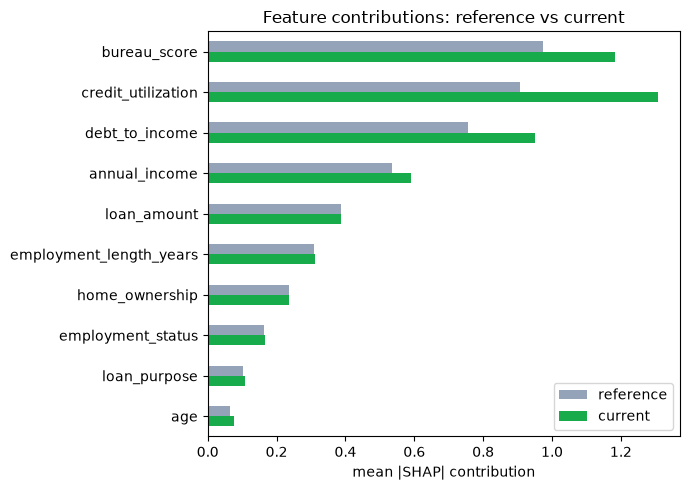

In [7]:
order = ref_attr.sort_values(ascending=False).index
ax = (
    pd.DataFrame({"reference": ref_attr, "current": cur_attr})
    .loc[order]
    .plot.barh(figsize=(7, 5), color=["#94a3b8", "#18ab4b"])
)
ax.invert_yaxis()
ax.set_xlabel("mean |SHAP| contribution")
ax.set_title("Feature contributions: reference vs current")
plt.tight_layout()
plt.show()

<link rel="stylesheet" href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/5.15.3/css/all.min.css">

<h2><i class="fas fa-cloud" style="color:#18ab4b"></i>&nbsp; On AWS</h2>

In `local` mode the cells above *are* the monitor. In `aws` mode the same `src/` runs as a SageMaker Processing job on the pipeline's schedule, writing these PSI and attribution metrics to CloudWatch under `NAMESPACE`; the cell below reads them back rather than recomputing them.

In [8]:
if MODE == "aws":
    import boto3

    cw = boto3.client("cloudwatch", region_name=REGION)
    metrics = cw.list_metrics(Namespace=NAMESPACE).get("Metrics", [])
    print(f"{len(metrics)} metrics published under {NAMESPACE}")
    for m in metrics[:10]:
        print(
            " ",
            m["MetricName"],
            {d["Name"]: d["Value"] for d in m.get("Dimensions", [])},
        )
else:
    print(
        "local mode: drift computed in-process above; set MODE='aws' to read CloudWatch"
    )

local mode: drift computed in-process above; set MODE='aws' to read CloudWatch


<i aria-hidden="true" class="fas fa-clipboard-check" style="color:#18ab4b"></i> **Expected output:** in local mode, a note that drift was computed in-process; the AWS branch would instead list CloudWatch metrics:

```plain
local mode: drift computed in-process above; set MODE='aws' to read CloudWatch
```

---
*On AWS this same monitoring code runs as a SageMaker Processing step (`aws/`, the pipeline's monitor), emitting the PSI and SHAP-attribution metrics to CloudWatch. This notebook is the narrative view of the same tested `src/`.*